In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
from rasterio.features import geometry_mask
from rasterio.transform import from_bounds

# ---------------------------------------------------
# INPUTS
# ---------------------------------------------------
combiprecip_path = "/storage/homefs/ge24z347/Zell_event/Data_forprocess/Combiprecip/CPC_00060_H_20240624000000_20240630230000.nc"
catchment_file = "/storage/homefs/ge24z347/Zell_event/Data_forprocess/domain_Morges_alert_final.gpkg"

var_name = "CPC"
time_dim = "REFERENCE_TS"

start_time = np.datetime64("2024-06-25T16:00:00.000000000")
end_time   = np.datetime64("2024-06-26T00:00:00.000000000")

out_csv = "/storage/homefs/ge24z347/Zell_event/MORGES_PLOTS/Morges_excel_accumulation/morges_combiprecip_hourly_intervals_20250625_1600_to_20250626_0000.csv"

# ---------------------------------------------------
# LOAD DATA
# ---------------------------------------------------
ds = xr.open_dataset(combiprecip_path)
da = ds[var_name]

print("Variable attrs:")
print(da.attrs)

# ---------------------------------------------------
# SELECT TIME PERIOD
# ---------------------------------------------------
da_time = da.sel({time_dim: slice(start_time, end_time)})

if da_time.sizes[time_dim] == 0:
    raise ValueError("No timesteps found in the selected time period.")

times = da_time[time_dim].values

print("\nSelected timestamps:")
print(times)
print("Number of timestamps:", len(times))

if len(times) < 2:
    raise ValueError("Need at least 2 timestamps to build hourly intervals.")

# ---------------------------------------------------
# LOAD CATCHMENT
# ---------------------------------------------------
gdf = gpd.read_file(catchment_file)

if gdf.empty:
    raise ValueError("Catchment file is empty.")

if gdf.crs is not None and gdf.crs.to_epsg() != 2056:
    gdf = gdf.to_crs("EPSG:2056")

catchment_geom = gdf.geometry.union_all()

# ---------------------------------------------------
# BUILD MASK
# ---------------------------------------------------
x = da_time["x"].values
y = da_time["y"].values

nx = len(x)
ny = len(y)

xmin, xmax = float(x.min()), float(x.max())
ymin, ymax = float(y.min()), float(y.max())

transform = from_bounds(xmin, ymin, xmax, ymax, nx, ny)

mask = geometry_mask(
    [catchment_geom],
    transform=transform,
    invert=True,
    out_shape=(ny, nx)
)

if y[0] < y[-1]:
    mask = np.flipud(mask)

print("Pixels inside catchment:", int(mask.sum()))

if mask.sum() == 0:
    raise ValueError("Catchment mask is empty. Check CRS and overlap.")

# ---------------------------------------------------
# METRICS PER HOURLY INTERVAL
# ---------------------------------------------------
rows = []

for i in range(len(times) - 1):
    t0 = times[i]
    t1 = times[i + 1]

    # Select the field at the starting hour of the interval
    # If your dataset stores hourly precipitation "for that hour",
    # this is usually the correct value to use.
    da_interval = da.sel({time_dim: t0})

    arr = da_interval.values
    arr_masked = np.where(mask, arr, np.nan)
    valid = arr_masked[np.isfinite(arr_masked)]

    if len(valid) == 0:
        interval_sum = np.nan
        interval_mean = np.nan
        interval_p80 = np.nan
        interval_p90 = np.nan
        interval_p99_9 = np.nan
        interval_max = np.nan
        n_pixels = 0
    else:
        interval_sum = np.sum(valid)
        interval_mean = np.mean(valid)
        interval_p80 = np.percentile(valid, 80)
        interval_p90 = np.percentile(valid, 90)
        interval_p99_9 = np.percentile(valid, 99.9)
        interval_max = np.max(valid)
        n_pixels = len(valid)

    rows.append({
        "interval_start": pd.Timestamp(t0),
        "interval_end": pd.Timestamp(t1),
        "n_pixels": n_pixels,
        "sum": interval_sum,
        "mean": interval_mean,
        "p80": interval_p80,
        "p90": interval_p90,
        "p99_9": interval_p99_9,
        "max": interval_max
    })

df_hourly = pd.DataFrame(rows)

pd.set_option("display.float_format", "{:.10f}".format)

print("\nHourly interval metrics over catchment:")
print(df_hourly)

# ---------------------------------------------------
# SAVE
# ---------------------------------------------------
df_hourly.to_csv(out_csv, index=False)

print("\nSaved:")
print(out_csv)

Variable attrs:
{'QualityCode0': 'Qr=9, Qw=2, Qcpc=1', 'esri_pe_string': 'PROJCS["CH1903+_LV95",GEOGCS["GCS_CH1903+",DATUM["D_CH1903+",SPHEROID["Bessel_1841",6377397.155,299.1528128]],PRIMEM["Greenwich",0],UNIT["Degree",0.017453292519943295]],PROJECTION["Hotine_Oblique_Mercator_Azimuth_Center"],PARAMETER["latitude_of_center",46.95240555555556],PARAMETER["longitude_of_center",7.439583333333333],PARAMETER["azimuth",90],PARAMETER["scale_factor",1],PARAMETER["false_easting",2600000],PARAMETER["false_northing",1200000],UNIT["Meter",1]]'}

Selected timestamps:
['2024-06-25T16:00:00.000000000' '2024-06-25T17:00:00.000000000'
 '2024-06-25T18:00:00.000000000' '2024-06-25T19:00:00.000000000'
 '2024-06-25T20:00:00.000000000' '2024-06-25T21:00:00.000000000'
 '2024-06-25T22:00:00.000000000' '2024-06-25T23:00:00.000000000'
 '2024-06-26T00:00:00.000000000']
Number of timestamps: 9
Pixels inside catchment: 33

Hourly interval metrics over catchment:
       interval_start        interval_end  n_pixels 

/storage/homefs/ge24z347/mambaforge/envs/env_py311/lib/python3.11/site-packages/pyogrio/geopandas.py:265: UserWarning: More than one layer found in 'domain_Morges_alert_final.gpkg': 'domain_Morges_alert_final.' (default), 'domain_morges_alert_final'. Specify layer parameter to avoid this warning.
  result = read_func(



Saved:
/storage/homefs/ge24z347/Zell_event/MORGES_PLOTS/Morges_excel_accumulation/morges_combiprecip_hourly_intervals_20250625_1600_to_20250626_0000.csv


Variable attributes:
{'QualityCode0': 'Qr=9, Qw=2, Qcpc=1', 'esri_pe_string': 'PROJCS["CH1903+_LV95",GEOGCS["GCS_CH1903+",DATUM["D_CH1903+",SPHEROID["Bessel_1841",6377397.155,299.1528128]],PRIMEM["Greenwich",0],UNIT["Degree",0.017453292519943295]],PROJECTION["Hotine_Oblique_Mercator_Azimuth_Center"],PARAMETER["latitude_of_center",46.95240555555556],PARAMETER["longitude_of_center",7.439583333333333],PARAMETER["azimuth",90],PARAMETER["scale_factor",1],PARAMETER["false_easting",2600000],PARAMETER["false_northing",1200000],UNIT["Meter",1]]'}

Selected timestamps:
['2024-06-25T13:00:00.000000000' '2024-06-25T14:00:00.000000000'
 '2024-06-25T15:00:00.000000000' '2024-06-25T16:00:00.000000000'
 '2024-06-25T17:00:00.000000000' '2024-06-25T18:00:00.000000000'
 '2024-06-25T19:00:00.000000000' '2024-06-25T20:00:00.000000000'
 '2024-06-25T21:00:00.000000000' '2024-06-25T22:00:00.000000000'
 '2024-06-25T23:00:00.000000000' '2024-06-26T00:00:00.000000000']
Number of timestamps: 12


/storage/homefs/ge24z347/mambaforge/envs/env_py311/lib/python3.11/site-packages/pyogrio/geopandas.py:265: UserWarning: More than one layer found in 'domain_Morges_alert_final.gpkg': 'domain_Morges_alert_final.' (default), 'domain_morges_alert_final'. Specify layer parameter to avoid this warning.
  result = read_func(


Pixels inside catchment: 33

Hourly results:
        interval_start        interval_end  n_pixels          sum       mean  \
0  2024-06-25 13:00:00 2024-06-25 14:00:00        33     0.439283   0.013312   
1  2024-06-25 14:00:00 2024-06-25 15:00:00        33     0.469654   0.014232   
2  2024-06-25 15:00:00 2024-06-25 16:00:00        33     0.470664   0.014263   
3  2024-06-25 16:00:00 2024-06-25 17:00:00        33    84.537621   2.561746   
4  2024-06-25 17:00:00 2024-06-25 18:00:00        33  1601.675049  48.535606   
5  2024-06-25 18:00:00 2024-06-25 19:00:00        33   588.012024  17.818546   
6  2024-06-25 19:00:00 2024-06-25 20:00:00        33    47.220661   1.430929   
7  2024-06-25 20:00:00 2024-06-25 21:00:00        33    27.341572   0.828532   
8  2024-06-25 21:00:00 2024-06-25 22:00:00        33     1.804400   0.054679   
9  2024-06-25 22:00:00 2024-06-25 23:00:00        33     0.000000   0.000000   
10 2024-06-25 23:00:00 2024-06-26 00:00:00        33     0.000000   0.00000

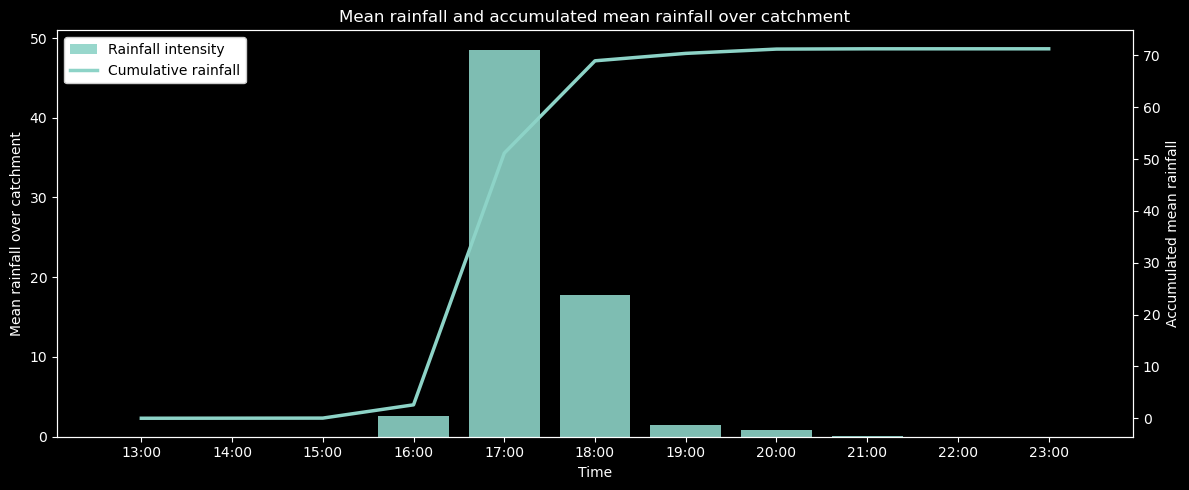


Saved figure:
/storage/homefs/ge24z347/Zell_event/MORGES_PLOTS/Morges_excel_accumulation/morges_hourly_mean_and_cumulative_over_catchment.png


In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.features import geometry_mask
from rasterio.transform import from_bounds

# ---------------------------------------------------
# INPUTS
# ---------------------------------------------------
combiprecip_path = "/storage/homefs/ge24z347/Zell_event/Data_forprocess/Combiprecip/CPC_00060_H_20240624000000_20240630230000.nc"
catchment_file = "/storage/homefs/ge24z347/Zell_event/Data_forprocess/domain_Morges_alert_final.gpkg"

var_name = "CPC"
time_dim = "REFERENCE_TS"

start_time = np.datetime64("2024-06-25T13:00:00")
end_time   = np.datetime64("2024-06-26T00:00:00")

out_csv = "/storage/homefs/ge24z347/Zell_event/MORGES_PLOTS/Morges_excel_accumulation/morges_hourly_mean_over_catchment.csv"
out_png = "/storage/homefs/ge24z347/Zell_event/MORGES_PLOTS/Morges_excel_accumulation/morges_hourly_mean_and_cumulative_over_catchment.png"

# Same color feeling as your example
mint = "#8dd3c7"

# ---------------------------------------------------
# LOAD NETCDF
# ---------------------------------------------------
ds = xr.open_dataset(combiprecip_path)
da = ds[var_name]

print("Variable attributes:")
print(da.attrs)

# ---------------------------------------------------
# SELECT TIME PERIOD
# ---------------------------------------------------
da_time = da.sel({time_dim: slice(start_time, end_time)})

if da_time.sizes[time_dim] == 0:
    raise ValueError("No timesteps found in the selected time period.")

times = da_time[time_dim].values

print("\nSelected timestamps:")
print(times)
print("Number of timestamps:", len(times))

if len(times) < 2:
    raise ValueError("Need at least 2 timestamps to build hourly intervals.")

# ---------------------------------------------------
# LOAD CATCHMENT
# ---------------------------------------------------
gdf = gpd.read_file(catchment_file)

if gdf.empty:
    raise ValueError("Catchment file is empty.")

if gdf.crs is None:
    raise ValueError("Catchment CRS is missing.")

if gdf.crs.to_epsg() != 2056:
    gdf = gdf.to_crs("EPSG:2056")

catchment_geom = gdf.geometry.union_all()

# ---------------------------------------------------
# BUILD MASK
# ---------------------------------------------------
x = da_time["x"].values
y = da_time["y"].values

nx = len(x)
ny = len(y)

xmin, xmax = float(x.min()), float(x.max())
ymin, ymax = float(y.min()), float(y.max())

transform = from_bounds(xmin, ymin, xmax, ymax, nx, ny)

mask = geometry_mask(
    [catchment_geom],
    transform=transform,
    invert=True,
    out_shape=(ny, nx)
)

# Flip mask if y increases upward in array indexing
if y[0] < y[-1]:
    mask = np.flipud(mask)

print("Pixels inside catchment:", int(mask.sum()))

if mask.sum() == 0:
    raise ValueError("Catchment mask is empty. Check CRS and overlap.")

# ---------------------------------------------------
# CALCULATE HOURLY MEAN OVER CATCHMENT
# ---------------------------------------------------
rows = []

for i in range(len(times) - 1):
    t0 = times[i]
    t1 = times[i + 1]

    # field at start of interval
    da_interval = da.sel({time_dim: t0})

    arr = da_interval.values
    arr_masked = np.where(mask, arr, np.nan)
    valid = arr_masked[np.isfinite(arr_masked)]

    if len(valid) == 0:
        interval_sum = np.nan
        interval_mean = np.nan
        n_pixels = 0
    else:
        interval_sum = np.sum(valid)
        interval_mean = interval_sum / len(valid)   # spatial mean over catchment
        n_pixels = len(valid)

    rows.append({
        "interval_start": pd.Timestamp(t0),
        "interval_end": pd.Timestamp(t1),
        "n_pixels": n_pixels,
        "sum": interval_sum,
        "mean": interval_mean
    })

df_hourly = pd.DataFrame(rows)

# accumulated mean
df_hourly["cum_mean"] = df_hourly["mean"].cumsum()

print("\nHourly results:")
print(df_hourly)

# ---------------------------------------------------
# SAVE TABLE
# ---------------------------------------------------
df_hourly.to_csv(out_csv, index=False)
print("\nSaved CSV:")
print(out_csv)

# ---------------------------------------------------
# PLOT
# ---------------------------------------------------
labels = [t.strftime("%H:%M") for t in df_hourly["interval_start"]]

fig, ax1 = plt.subplots(figsize=(12, 5), facecolor="black")
ax1.set_facecolor("black")

# Bars: hourly mean
bars = ax1.bar(
    labels,
    df_hourly["mean"],
    width=0.78,
    color=mint,
    alpha=0.9,
    label="Rainfall intensity"
)

ax1.set_xlabel("Time", color="white")
ax1.set_ylabel("Mean rainfall over catchment", color="white")
ax1.tick_params(axis="x", colors="white", rotation=0)
ax1.tick_params(axis="y", colors="white")
for spine in ax1.spines.values():
    spine.set_color("white")

# Line: accumulated mean
ax2 = ax1.twinx()
ax2.plot(
    labels,
    df_hourly["cum_mean"],
    color=mint,
    linewidth=2.5,
    label="Cumulative rainfall"
)
ax2.set_ylabel("Accumulated mean rainfall", color="white")
ax2.tick_params(axis="y", colors="white")
for spine in ax2.spines.values():
    spine.set_color("white")

# Legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
leg = ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    facecolor="white",
    framealpha=1
)

plt.title("Mean rainfall and accumulated mean rainfall over catchment", color="white")
plt.tight_layout()
plt.savefig(out_png, dpi=300, facecolor=fig.get_facecolor(), bbox_inches="tight")
plt.show()

print("\nSaved figure:")
print(out_png)

Variable attributes:
{'QualityCode0': 'Qr=9, Qw=2, Qcpc=1', 'esri_pe_string': 'PROJCS["CH1903+_LV95",GEOGCS["GCS_CH1903+",DATUM["D_CH1903+",SPHEROID["Bessel_1841",6377397.155,299.1528128]],PRIMEM["Greenwich",0],UNIT["Degree",0.017453292519943295]],PROJECTION["Hotine_Oblique_Mercator_Azimuth_Center"],PARAMETER["latitude_of_center",46.95240555555556],PARAMETER["longitude_of_center",7.439583333333333],PARAMETER["azimuth",90],PARAMETER["scale_factor",1],PARAMETER["false_easting",2600000],PARAMETER["false_northing",1200000],UNIT["Meter",1]]'}

Selected timestamps:
['2024-06-25T13:00:00.000000000' '2024-06-25T14:00:00.000000000'
 '2024-06-25T15:00:00.000000000' '2024-06-25T16:00:00.000000000'
 '2024-06-25T17:00:00.000000000' '2024-06-25T18:00:00.000000000'
 '2024-06-25T19:00:00.000000000' '2024-06-25T20:00:00.000000000'
 '2024-06-25T21:00:00.000000000' '2024-06-25T22:00:00.000000000'
 '2024-06-25T23:00:00.000000000' '2024-06-26T00:00:00.000000000']
Number of timestamps: 12
Pixels inside catc

/storage/homefs/ge24z347/mambaforge/envs/env_py311/lib/python3.11/site-packages/pyogrio/geopandas.py:265: UserWarning: More than one layer found in 'domain_Morges_alert_final.gpkg': 'domain_Morges_alert_final.' (default), 'domain_morges_alert_final'. Specify layer parameter to avoid this warning.
  result = read_func(


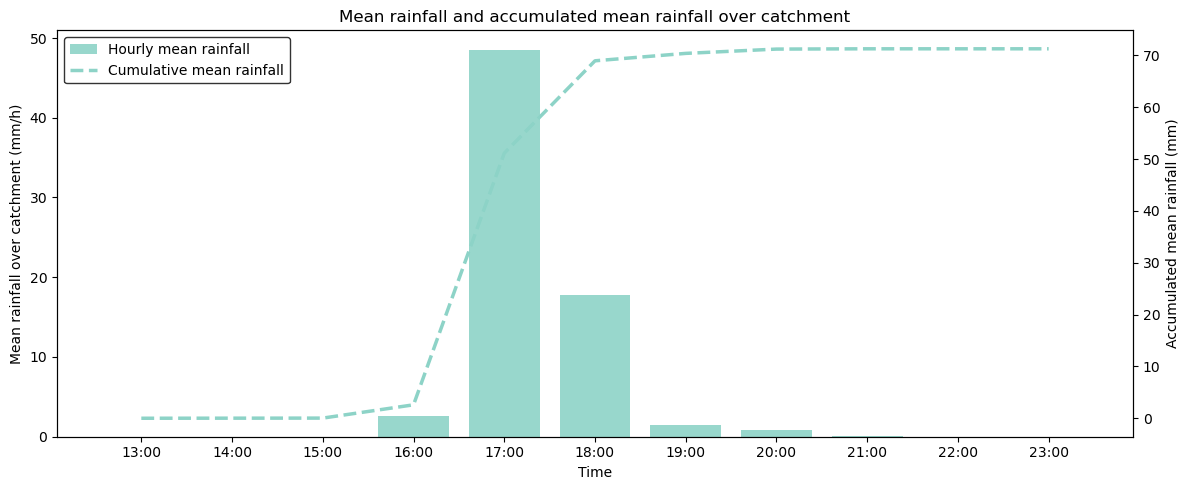


Saved figure:
/storage/homefs/ge24z347/Zell_event/MORGES_PLOTS/Morges_excel_accumulation/morges_hourly_mean_and_cumulative_over_catchment.png


In [7]:
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.features import geometry_mask
from rasterio.transform import from_bounds

# ---------------------------------------------------
# INPUTS
# ---------------------------------------------------
combiprecip_path = "/storage/homefs/ge24z347/Zell_event/Data_forprocess/Combiprecip/CPC_00060_H_20240624000000_20240630230000.nc"
catchment_file = "/storage/homefs/ge24z347/Zell_event/Data_forprocess/domain_Morges_alert_final.gpkg"

var_name = "CPC"
time_dim = "REFERENCE_TS"

start_time = np.datetime64("2024-06-25T13:00:00")
end_time   = np.datetime64("2024-06-26T00:00:00")

out_csv = "/storage/homefs/ge24z347/Zell_event/MORGES_PLOTS/Morges_excel_accumulation/morges_hourly_mean_p90_over_catchment.csv"
out_png = "/storage/homefs/ge24z347/Zell_event/MORGES_PLOTS/Morges_excel_accumulation/morges_hourly_mean_and_cumulative_over_catchment.png"
out_summary_csv = "/storage/homefs/ge24z347/Zell_event/MORGES_PLOTS/Morges_excel_accumulation/morges_event_summary_mean_p90_over_catchment.csv"

# Colors
mint = "#8dd3c7"

# ---------------------------------------------------
# USER-DEFINED SETTINGS FOR EVENT SUMMARY
# ---------------------------------------------------
event_threshold = 2  # mm/h; threshold to count an hour as part of the event
impact_peak_time = pd.Timestamp("2024-06-25 19:00:00")

# ---------------------------------------------------
# LOAD NETCDF
# ---------------------------------------------------
ds = xr.open_dataset(combiprecip_path)
da = ds[var_name]

print("Variable attributes:")
print(da.attrs)

# ---------------------------------------------------
# SELECT TIME PERIOD
# ---------------------------------------------------
da_time = da.sel({time_dim: slice(start_time, end_time)})

if da_time.sizes[time_dim] == 0:
    raise ValueError("No timesteps found in the selected time period.")

times = da_time[time_dim].values

print("\nSelected timestamps:")
print(times)
print("Number of timestamps:", len(times))

if len(times) < 2:
    raise ValueError("Need at least 2 timestamps to build hourly intervals.")

# ---------------------------------------------------
# LOAD CATCHMENT
# ---------------------------------------------------
gdf = gpd.read_file(catchment_file)

if gdf.empty:
    raise ValueError("Catchment file is empty.")

if gdf.crs is None:
    raise ValueError("Catchment CRS is missing.")

if gdf.crs.to_epsg() != 2056:
    gdf = gdf.to_crs("EPSG:2056")

catchment_geom = gdf.geometry.union_all()

# ---------------------------------------------------
# BUILD MASK
# ---------------------------------------------------
x = da_time["x"].values
y = da_time["y"].values

nx = len(x)
ny = len(y)

xmin, xmax = float(x.min()), float(x.max())
ymin, ymax = float(y.min()), float(y.max())

transform = from_bounds(xmin, ymin, xmax, ymax, nx, ny)

mask = geometry_mask(
    [catchment_geom],
    transform=transform,
    invert=True,
    out_shape=(ny, nx)
)

# Flip mask if y increases upward in array indexing
if y[0] < y[-1]:
    mask = np.flipud(mask)

print("Pixels inside catchment:", int(mask.sum()))

if mask.sum() == 0:
    raise ValueError("Catchment mask is empty. Check CRS and overlap.")

# ---------------------------------------------------
# CALCULATE HOURLY AGGREGATION OVER CATCHMENT
# ---------------------------------------------------
rows = []

for i in range(len(times) - 1):
    t0 = times[i]
    t1 = times[i + 1]

    # field at start of interval
    da_interval = da.sel({time_dim: t0})

    arr = da_interval.values
    arr_masked = np.where(mask, arr, np.nan)
    valid = arr_masked[np.isfinite(arr_masked)]

    if len(valid) == 0:
        interval_sum = np.nan
        interval_mean = np.nan
        interval_p90 = np.nan
        n_pixels = 0
    else:
        interval_sum = np.sum(valid)
        interval_mean = np.mean(valid)
        interval_p90 = np.percentile(valid, 90)
        n_pixels = len(valid)

    rows.append({
        "interval_start": pd.Timestamp(t0),
        "interval_end": pd.Timestamp(t1),
        "n_pixels": n_pixels,
        "sum": interval_sum,
        "mean": interval_mean,
        "p90": interval_p90
    })

df_hourly = pd.DataFrame(rows)

# accumulated values
df_hourly["cum_mean"] = df_hourly["mean"].cumsum()
df_hourly["cum_p90"] = df_hourly["p90"].cumsum()

# ---------------------------------------------------
# EVENT SUMMARY METRICS
# ---------------------------------------------------
df_hourly["is_event_mean"] = df_hourly["mean"] > event_threshold
df_hourly["is_event_p90"] = df_hourly["p90"] > event_threshold

# Peak 1-hour rainfall based on mean
if df_hourly["mean"].notna().any():
    peak_idx_mean = df_hourly["mean"].idxmax()
    peak_row_mean = df_hourly.loc[peak_idx_mean]
    peak_hour_start_mean = peak_row_mean["interval_start"]
    peak_hour_end_mean = peak_row_mean["interval_end"]
    peak_1h_mean = peak_row_mean["mean"]
else:
    peak_hour_start_mean = pd.NaT
    peak_hour_end_mean = pd.NaT
    peak_1h_mean = np.nan

# Peak 1-hour rainfall based on p90
if df_hourly["p90"].notna().any():
    peak_idx_p90 = df_hourly["p90"].idxmax()
    peak_row_p90 = df_hourly.loc[peak_idx_p90]
    peak_hour_start_p90 = peak_row_p90["interval_start"]
    peak_hour_end_p90 = peak_row_p90["interval_end"]
    peak_1h_p90 = peak_row_p90["p90"]
else:
    peak_hour_start_p90 = pd.NaT
    peak_hour_end_p90 = pd.NaT
    peak_1h_p90 = np.nan

# Event duration in hours above threshold
event_duration_hours_mean = int(df_hourly["is_event_mean"].sum())
event_duration_hours_p90 = int(df_hourly["is_event_p90"].sum())

# Total event rainfall over catchment
total_event_mean = df_hourly["mean"].sum()
total_event_p90 = df_hourly["p90"].sum()

# Rainfall at 17:00
rain_at_17_mean = df_hourly.loc[
    df_hourly["interval_start"] == pd.Timestamp("2024-06-25 17:00:00"),
    "mean"
]
rain_at_17_mean = rain_at_17_mean.iloc[0] if len(rain_at_17_mean) > 0 else np.nan

rain_at_17_p90 = df_hourly.loc[
    df_hourly["interval_start"] == pd.Timestamp("2024-06-25 17:00:00"),
    "p90"
]
rain_at_17_p90 = rain_at_17_p90.iloc[0] if len(rain_at_17_p90) > 0 else np.nan

# Rainfall from 17:00 to 19:00
rain_17_19_mean = df_hourly.loc[
    (df_hourly["interval_start"] >= pd.Timestamp("2024-06-25 17:00:00")) &
    (df_hourly["interval_start"] <  pd.Timestamp("2024-06-25 19:00:00")),
    "mean"
].sum()

rain_17_19_p90 = df_hourly.loc[
    (df_hourly["interval_start"] >= pd.Timestamp("2024-06-25 17:00:00")) &
    (df_hourly["interval_start"] <  pd.Timestamp("2024-06-25 19:00:00")),
    "p90"
].sum()

# Rainfall from 16:00 to 19:00
rain_16_19_mean = df_hourly.loc[
    (df_hourly["interval_start"] >= pd.Timestamp("2024-06-25 16:00:00")) &
    (df_hourly["interval_start"] <  pd.Timestamp("2024-06-25 19:00:00")),
    "mean"
].sum()

rain_16_19_p90 = df_hourly.loc[
    (df_hourly["interval_start"] >= pd.Timestamp("2024-06-25 16:00:00")) &
    (df_hourly["interval_start"] <  pd.Timestamp("2024-06-25 19:00:00")),
    "p90"
].sum()

# 2-hour accumulation before impact peak
rain_2h_before_peak_mean = df_hourly.loc[
    (df_hourly["interval_start"] >= impact_peak_time - pd.Timedelta(hours=2)) &
    (df_hourly["interval_start"] <  impact_peak_time),
    "mean"
].sum()

rain_2h_before_peak_p90 = df_hourly.loc[
    (df_hourly["interval_start"] >= impact_peak_time - pd.Timedelta(hours=2)) &
    (df_hourly["interval_start"] <  impact_peak_time),
    "p90"
].sum()

# 3-hour accumulation before impact peak
rain_3h_before_peak_mean = df_hourly.loc[
    (df_hourly["interval_start"] >= impact_peak_time - pd.Timedelta(hours=3)) &
    (df_hourly["interval_start"] <  impact_peak_time),
    "mean"
].sum()

rain_3h_before_peak_p90 = df_hourly.loc[
    (df_hourly["interval_start"] >= impact_peak_time - pd.Timedelta(hours=3)) &
    (df_hourly["interval_start"] <  impact_peak_time),
    "p90"
].sum()

# First and last event hour above threshold based on mean
event_rows_mean = df_hourly[df_hourly["is_event_mean"]]
if not event_rows_mean.empty:
    event_start_mean = event_rows_mean["interval_start"].iloc[0]
    event_end_mean = event_rows_mean["interval_end"].iloc[-1]
else:
    event_start_mean = pd.NaT
    event_end_mean = pd.NaT

# First and last event hour above threshold based on p90
event_rows_p90 = df_hourly[df_hourly["is_event_p90"]]
if not event_rows_p90.empty:
    event_start_p90 = event_rows_p90["interval_start"].iloc[0]
    event_end_p90 = event_rows_p90["interval_end"].iloc[-1]
else:
    event_start_p90 = pd.NaT
    event_end_p90 = pd.NaT

# Summary table
df_summary = pd.DataFrame([{
    "impact_peak_time": impact_peak_time,

    "event_threshold_mm_h": event_threshold,

    "event_start_mean": event_start_mean,
    "event_end_mean": event_end_mean,
    "event_duration_hours_above_threshold_mean": event_duration_hours_mean,
    "peak_hour_start_mean": peak_hour_start_mean,
    "peak_hour_end_mean": peak_hour_end_mean,
    "peak_1h_mean_mm_h": peak_1h_mean,
    "rain_at_17_00_mean_mm_h": rain_at_17_mean,
    "rain_17_00_to_19_00_mean_mm": rain_17_19_mean,
    "rain_16_00_to_19_00_mean_mm": rain_16_19_mean,
    "rain_2h_before_impact_peak_mean_mm": rain_2h_before_peak_mean,
    "rain_3h_before_impact_peak_mean_mm": rain_3h_before_peak_mean,
    "total_event_mean_mm": total_event_mean,

    "event_start_p90": event_start_p90,
    "event_end_p90": event_end_p90,
    "event_duration_hours_above_threshold_p90": event_duration_hours_p90,
    "peak_hour_start_p90": peak_hour_start_p90,
    "peak_hour_end_p90": peak_hour_end_p90,
    "peak_1h_p90_mm_h": peak_1h_p90,
    "rain_at_17_00_p90_mm_h": rain_at_17_p90,
    "rain_17_00_to_19_00_p90_mm": rain_17_19_p90,
    "rain_16_00_to_19_00_p90_mm": rain_16_19_p90,
    "rain_2h_before_impact_peak_p90_mm": rain_2h_before_peak_p90,
    "rain_3h_before_impact_peak_p90_mm": rain_3h_before_peak_p90,
    "total_event_p90_mm": total_event_p90
}])

print("\nHourly results:")
print(df_hourly)

print("\nEvent summary:")
print(df_summary)

# ---------------------------------------------------
# SAVE TABLES
# ---------------------------------------------------
df_hourly.to_csv(out_csv, index=False)
print("\nSaved hourly CSV:")
print(out_csv)

df_summary.to_csv(out_summary_csv, index=False)
print("\nSaved summary CSV:")
print(out_summary_csv)

# ---------------------------------------------------
# PLOT - MEAN ONLY
# ---------------------------------------------------
labels = [t.strftime("%H:%M") for t in df_hourly["interval_start"]]

fig, ax1 = plt.subplots(figsize=(12, 5))
fig.patch.set_alpha(0)
ax1.set_facecolor("none")

# Bars: hourly mean
ax1.bar(
    labels,
    df_hourly["mean"],
    width=0.78,
    color=mint,
    alpha=0.9,
    label="Hourly mean rainfall"
)

ax1.set_xlabel("Time", color="black")
ax1.set_ylabel("Mean rainfall over catchment (mm/h)", color="black")
ax1.tick_params(axis="x", colors="black", rotation=0)
ax1.tick_params(axis="y", colors="black")
for spine in ax1.spines.values():
    spine.set_color("black")

# Secondary axis: cumulative mean
ax2 = ax1.twinx()
ax2.set_facecolor("none")
ax2.plot(
    labels,
    df_hourly["cum_mean"],
    color=mint,
    linewidth=2.5,
    linestyle="--",
    label="Cumulative mean rainfall"
)

ax2.set_ylabel("Accumulated mean rainfall (mm)", color="black")
ax2.tick_params(axis="y", colors="black")
for spine in ax2.spines.values():
    spine.set_color("black")

# Legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
legend = ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    frameon=True
)
legend.get_frame().set_facecolor("none")
legend.get_frame().set_edgecolor("black")
for text in legend.get_texts():
    text.set_color("black")

plt.title("Mean rainfall and accumulated mean rainfall over catchment", color="black")
plt.tight_layout()
plt.savefig(out_png, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("\nSaved figure:")
print(out_png)